# Step 4: Hosing with salinity restoring

How does the AMOC respond to 0.1, 0.3 and 0.5 Sv of extra freshwater in the subpolar North Atlantic, while surface salinity is still restored toward observations? And does it recover when the hosing stops? I also measure how much of the added freshwater the salinity restoring cancels out.

All runs start from the end of the spin-up (model year 2000). Each hosing run has hosing on for 200 years (2001-2200), then off for 300 years (2201-2500). The control continues with the original forcing for the same 500 years. The runs were made with `scripts/run_hosing_set.sh restore ...`.

I load the libraries and the shared AMOC functions from `src/amoc_tools.py` (the same calculation as in notebook 02), and set the paths and run names.

In [1]:
%matplotlib inline

import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../src")   # amoc_tools.py lives in the project's src/ folder
from amoc_tools import (read_grid, amoc_series, output_iterations, annual_field,
                        STEPS_PER_YEAR, SV, RHO_FRESH)

RUNS = os.path.expanduser("~/mitgcm_runs/hosing")
SET = "restore"
HOSING = {"010": 0.1, "030": 0.3, "050": 0.5}    # file code -> hosing strength (Sv)
HOSING_END = 2200                                # last model year with hosing
COLORS = {"control": "k", "010": "tab:blue", "030": "tab:orange", "050": "tab:red"}
AVERAGE_YEARS = 10                               # "end of hosing" and "end of recovery" = mean of the last 10 years
FIG_DIR = "../figures"
DATA_DIR = "../data"

I read the grid and masks once, from the spin-up run. All runs share the same grid.

In [2]:
grid = read_grid(os.path.join(RUNS, "spinup"), DATA_DIR)
print("Atlantic cells:", grid["atlantic"].sum(), "| hosing-region cells:", grid["region"].sum())

Atlantic cells: 460 | hosing-region cells: 87


I check that every run ended normally and that the pickup at the end of hosing (step 792000, year 2200) exists, because the "off" runs started from it.

In [3]:
run_names = [f"{SET}_control"]
for code in HOSING:
    run_names += [f"{SET}_hose{code}_on", f"{SET}_hose{code}_off"]
for name in run_names:
    text = open(os.path.join(RUNS, name, "output.txt")).read()
    years = output_iterations(os.path.join(RUNS, name), "vvel_annual")
    print(f"{name:22s} ended normally: {'Execution ended Normally' in text} | annual means: {len(years)} "
          f"(years {years[0] / STEPS_PER_YEAR:.0f}-{years[-1] / STEPS_PER_YEAR:.0f})")
for code in HOSING:
    path = os.path.join(RUNS, f"{SET}_hose{code}_on", "pickup.0000792000.data")
    print(f"pickup at year 2200 for hose{code}: {os.path.exists(path)}")

restore_control        ended normally: True | annual means: 500 (years 2001-2500)
restore_hose010_on     ended normally: True | annual means: 200 (years 2001-2200)
restore_hose010_off    ended normally: True | annual means: 300 (years 2201-2500)
restore_hose030_on     ended normally: True | annual means: 200 (years 2001-2200)
restore_hose030_off    ended normally: True | annual means: 300 (years 2201-2500)
restore_hose050_on     ended normally: True | annual means: 200 (years 2001-2200)
restore_hose050_off    ended normally: True | annual means: 300 (years 2201-2500)
pickup at year 2200 for hose010: True
pickup at year 2200 for hose030: True
pickup at year 2200 for hose050: True


I compute the AMOC index for every year of every run. For a hosing run I join the "on" and "off" parts into one 500-year series. I also take the last 100 years of the spin-up, to show the starting point.

In [4]:
amoc = {}
years_spin, amoc_spin = amoc_series([os.path.join(RUNS, "spinup")], grid)
keep = years_spin > years_spin[-1] - 100
years, amoc["control"] = amoc_series([os.path.join(RUNS, f"{SET}_control")], grid)
for code in HOSING:
    years_h, amoc[code] = amoc_series([os.path.join(RUNS, f"{SET}_hose{code}_on"),
                                       os.path.join(RUNS, f"{SET}_hose{code}_off")], grid)
    assert np.array_equal(years_h, years), "hosing and control years must match"
print(f"years {years[0]:.0f}-{years[-1]:.0f}, {len(years)} values per run")

years 2001-2500, 500 values per run


I save the four AMOC series in one small CSV file, so the comparison in step 7 does not need the raw output.

In [5]:
csv_path = os.path.join(DATA_DIR, f"amoc_index_{SET}.csv")
with open(csv_path, "w") as f:
    f.write("model_year,control_sv," + ",".join(f"hose{code}_sv" for code in HOSING) + "\n")
    for n in range(len(years)):
        values = [amoc["control"][n]] + [amoc[code][n] for code in HOSING]
        f.write(f"{years[n]:.0f}," + ",".join(f"{v:.4f}" for v in values) + "\n")
print("saved", csv_path)

saved ../data/amoc_index_restore.csv


This figure shows the AMOC index for all runs. The grey band marks the 200 years of hosing.

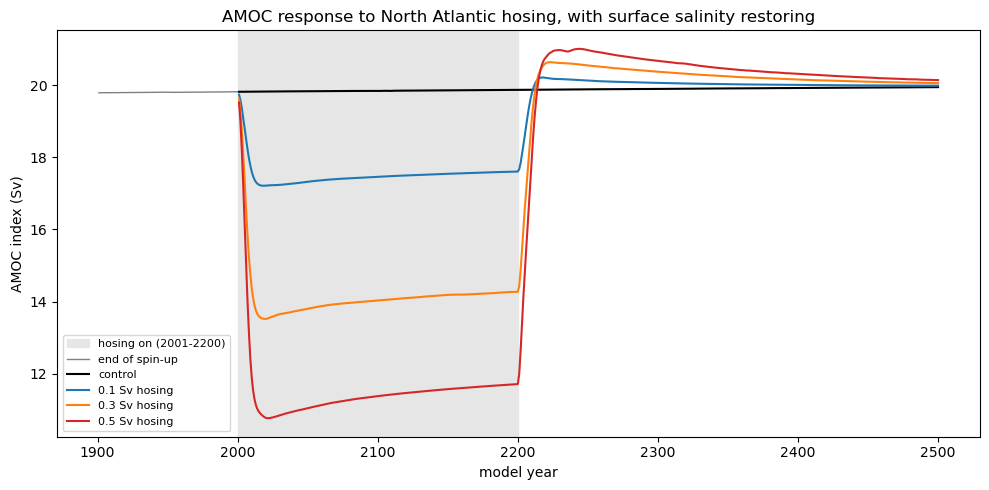

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axvspan(2000, HOSING_END, color="0.9", label="hosing on (2001-2200)")
ax.plot(years_spin[keep], amoc_spin[keep], color="0.5", lw=1, label="end of spin-up")
ax.plot(years, amoc["control"], color=COLORS["control"], lw=1.5, label="control")
for code, strength in HOSING.items():
    ax.plot(years, amoc[code], color=COLORS[code], lw=1.5, label=f"{strength} Sv hosing")
ax.set_xlabel("model year")
ax.set_ylabel("AMOC index (Sv)")
ax.set_title("AMOC response to North Atlantic hosing, with surface salinity restoring")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_amoc_restoring.png"), dpi=150)
plt.show()

I summarise each run: the AMOC at the end of hosing and at the end of recovery (each the mean of the last 10 years, compared with the control over the same years), the lowest value, and the year it happened.

In [7]:
def mean_over(series, last_year, n_years):
    """Mean of a series over the n_years ending at last_year."""
    keep = (years > last_year - n_years) & (years <= last_year)
    return series[keep].mean()

control_end_hosing = mean_over(amoc["control"], HOSING_END, AVERAGE_YEARS)
control_end = mean_over(amoc["control"], years[-1], AVERAGE_YEARS)
print(f"control: {control_end_hosing:.2f} Sv at years 2191-2200, {control_end:.2f} Sv at years 2491-2500")
print()
print(f"{'hosing':>8s} {'end of hosing':>14s} {'change':>8s} {'change':>8s} {'end of recovery':>16s} {'change':>8s} {'minimum':>8s} {'year':>6s}")
summary = {}
for code, strength in HOSING.items():
    end_h = mean_over(amoc[code], HOSING_END, AVERAGE_YEARS)
    end_r = mean_over(amoc[code], years[-1], AVERAGE_YEARS)
    d_h = end_h - control_end_hosing
    d_r = end_r - control_end
    n_min = np.argmin(amoc[code])
    summary[code] = (end_h, d_h, end_r, d_r)
    print(f"{strength:6.1f} Sv {end_h:11.2f} Sv {d_h:+7.2f} {100 * d_h / control_end_hosing:+7.1f}% "
          f"{end_r:13.2f} Sv {d_r:+7.2f} {amoc[code][n_min]:8.2f} {years[n_min]:6.0f}")

control: 19.87 Sv at years 2191-2200, 19.94 Sv at years 2491-2500

  hosing  end of hosing   change   change  end of recovery   change  minimum   year
   0.1 Sv       17.60 Sv   -2.27   -11.4%         19.99 Sv   +0.04    17.21   2018
   0.3 Sv       14.27 Sv   -5.60   -28.2%         20.06 Sv   +0.11    13.52   2020
   0.5 Sv       11.70 Sv   -8.17   -41.1%         20.15 Sv   +0.20    10.77   2021


Now the restoring. Salinity restoring adds salt where the surface is fresher than observed, which works against the hosing. I turn the extra restoring salt flux (hosing run minus control) into the freshwater flux it is equivalent to: a salt flux F_s in g/m^2/s is the same as removing F_s / (1000 kg/m^3 x S) m/s of fresh water, where S is the local surface salinity in g/kg. That is the same conversion the model uses for EmPmR (`convertFW2Salt = -1`, local salinity). Summed over an area, this gives the cancelled freshwater in Sv.

In [8]:
def restoring_cancellation(run_dirs, control_dir, mask):
    """Freshwater (Sv) removed by the extra salinity restoring, hosing run minus control, over `mask`."""
    result = []
    area = grid["rac"] * mask
    for run_dir in run_dirs:
        for it in output_iterations(run_dir, "surf_flux_annual"):
            d_srelax = (annual_field(run_dir, "surf_flux_annual", "SRELAX", it)
                        - annual_field(control_dir, "surf_flux_annual", "SRELAX", it))   # extra salt flux, g/m^2/s
            sss = annual_field(run_dir, "surf_ts_annual", "SALT", it)                    # local surface salinity, g/kg
            freshwater_removed = np.zeros_like(d_srelax)
            ok = mask & (sss > 0)
            freshwater_removed[ok] = d_srelax[ok] / (RHO_FRESH * sss[ok])               # m/s
            result.append(np.sum(freshwater_removed * area) / SV)
    return np.array(result)

control_dir = os.path.join(RUNS, f"{SET}_control")
cancel_region = {}
cancel_global = {}
for code in HOSING:
    dirs = [os.path.join(RUNS, f"{SET}_hose{code}_on"), os.path.join(RUNS, f"{SET}_hose{code}_off")]
    cancel_region[code] = restoring_cancellation(dirs, control_dir, grid["region"])
    cancel_global[code] = restoring_cancellation(dirs, control_dir, grid["ocean"])
print("computed restoring cancellation for", list(HOSING.values()), "Sv")

computed restoring cancellation for [0.1, 0.3, 0.5] Sv


I print how much of the hosing the restoring cancels: in year 2001, as an average over the hosing years, and at the end of hosing. 'Region' counts only restoring inside the hosing region; 'global' counts it everywhere.

In [9]:
hosing_years = years <= HOSING_END
print(f"{'hosing':>8s} {'where':>7s} {'year 2001':>10s} {'2001-2200 mean':>15s} {'2191-2200 mean':>15s} {'fraction of hosing (2191-2200)':>31s}")
for code, strength in HOSING.items():
    for label, series in [("region", cancel_region[code]), ("global", cancel_global[code])]:
        late = series[hosing_years][-AVERAGE_YEARS:].mean()
        print(f"{strength:6.1f} Sv {label:>7s} {series[0]:10.3f} {series[hosing_years].mean():15.3f} {late:15.3f} "
              f"{100 * late / strength:30.0f}%")

  hosing   where  year 2001  2001-2200 mean  2191-2200 mean  fraction of hosing (2191-2200)
   0.1 Sv  region      0.044           0.081           0.080                             80%
   0.1 Sv  global      0.045           0.070           0.064                             64%
   0.3 Sv  region      0.132           0.250           0.250                             83%
   0.3 Sv  global      0.136           0.223           0.204                             68%
   0.5 Sv  region      0.224           0.437           0.437                             87%
   0.5 Sv  global      0.229           0.406           0.373                             75%


This figure shows the cancelled freshwater over time for each hosing strength. The dotted lines mark the hosing strength itself: if a curve reached its dotted line, the restoring would be cancelling all of the added water.

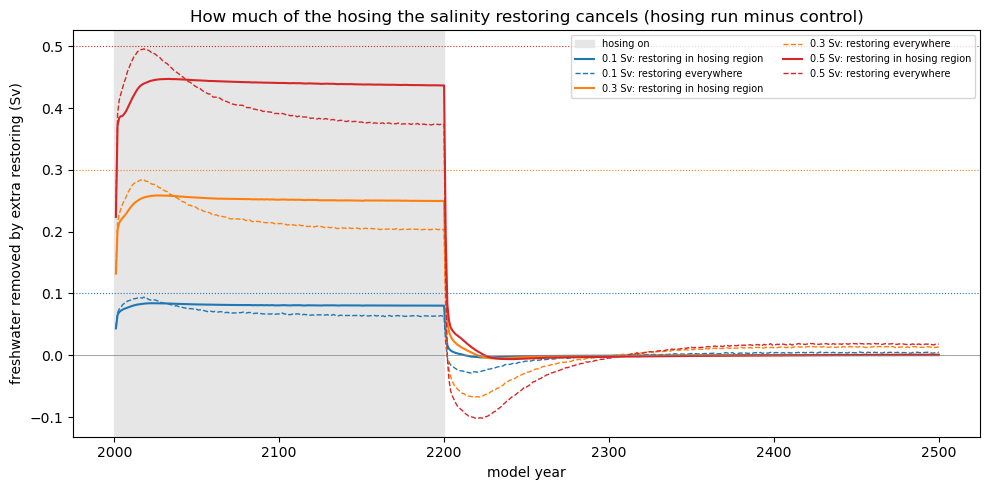

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.axvspan(2000, HOSING_END, color="0.9", label="hosing on")
for code, strength in HOSING.items():
    ax.plot(years, cancel_region[code], color=COLORS[code], lw=1.5, label=f"{strength} Sv: restoring in hosing region")
    ax.plot(years, cancel_global[code], color=COLORS[code], lw=1, ls="--", label=f"{strength} Sv: restoring everywhere")
    ax.axhline(strength, color=COLORS[code], lw=0.8, ls=":")
ax.axhline(0, color="0.5", lw=0.5)
ax.set_xlabel("model year")
ax.set_ylabel("freshwater removed by extra restoring (Sv)")
ax.set_title("How much of the hosing the salinity restoring cancels (hosing run minus control)")
ax.legend(fontsize=7, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "04_restoring_cancellation.png"), dpi=150)
plt.show()

I save the cancellation series too, for step 7.

In [11]:
csv_path = os.path.join(DATA_DIR, f"restoring_cancellation_{SET}.csv")
with open(csv_path, "w") as f:
    header = ["model_year"]
    for code in HOSING:
        header += [f"hose{code}_region_sv", f"hose{code}_global_sv"]
    f.write(",".join(header) + "\n")
    for n in range(len(years)):
        values = []
        for code in HOSING:
            values += [cancel_region[code][n], cancel_global[code][n]]
        f.write(f"{years[n]:.0f}," + ",".join(f"{v:.4f}" for v in values) + "\n")
print("saved", csv_path)

saved ../data/restoring_cancellation_restore.csv
